# 04 — Advanced Image Generation: Diffusion Models (DDPM)

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the **DDPM noise schedule** (β, α, ᾱ) and implement the **forward process** q(xₜ|x₀)
- Train a **noise-prediction denoiser** — the exact training objective inside Stable Diffusion
- Run the **reverse process**: denoise a corrupted real image step by step, and generate from pure noise
- Understand where **text conditioning** plugs in to make text-to-image systems (concept — running Stable Diffusion itself needs a GPU + model download)

## 🔗 Prerequisites

- ✅ Units 1–2 and examples 01–03 (VAEs/GANs — diffusion is the third family)
- ✅ CNN basics (Course 08) — the denoiser below is convolutional

---

## Introduction

**Diffusion models** generate by learning to reverse a gradual noising process:

- **Forward** (fixed, no learning): repeatedly add small Gaussian noise until the image is pure noise. Closed form: xₜ = √ᾱₜ·x₀ + √(1−ᾱₜ)·ε.
- **Reverse** (learned): a network predicts the noise ε in xₜ; stepping t = T…0 with that prediction turns noise back into an image.

Stable Diffusion adds two pieces to this exact core: it diffuses in a **VAE latent space** (example 01's architecture!) for efficiency, and conditions the denoiser on **text embeddings** so a prompt steers the reverse process.


PyTorch 2.13.0
alpha_bar at t=0: 0.9999   at t=T: 0.0061  (≈0 → pure noise)


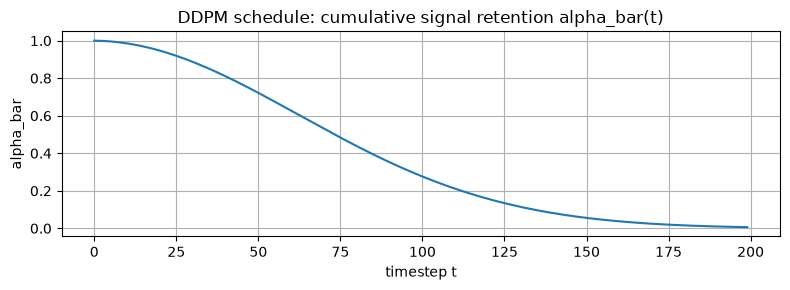

In [1]:
# WHAT/WHY: build the DDPM noise schedule and implement the forward process
# q(x_t | x_0) — then plot how much of the original signal survives at each
# timestep. This schedule drives everything else in the notebook.
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
print(f'PyTorch {torch.__version__}')

torch.manual_seed(0)
T_STEPS = 200
# Compressed linear schedule: real DDPM uses T=1000 with beta up to 0.02; with
# only 200 steps we raise beta_max to 0.05 so alpha_bar still reaches ~0 at T
# (otherwise "t = T" would not be pure noise and sampling could not start there).
betas  = torch.linspace(1e-4, 0.05, T_STEPS)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)     # cumulative signal retention
print(f"alpha_bar at t=0: {alpha_bar[0]:.4f}   at t=T: {alpha_bar[-1]:.4f}  (≈0 → pure noise)")

def q_sample(x0, t, noise=None):
    """Forward process: jump straight to timestep t in closed form."""
    if noise is None:
        noise = torch.randn_like(x0)
    a = alpha_bar[t].view(-1, 1, 1, 1)
    return a.sqrt() * x0 + (1 - a).sqrt() * noise, noise

# ── Plot the schedule (shown inline) ──────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(alpha_bar.numpy())
plt.title("DDPM schedule: cumulative signal retention alpha_bar(t)")
plt.xlabel("timestep t"); plt.ylabel("alpha_bar"); plt.grid(True)
plt.tight_layout(); plt.show()


## Forward Diffusion on Real Images

Watch a real MNIST digit dissolve into noise along the schedule — this is the *data-generating* process the model will learn to reverse.


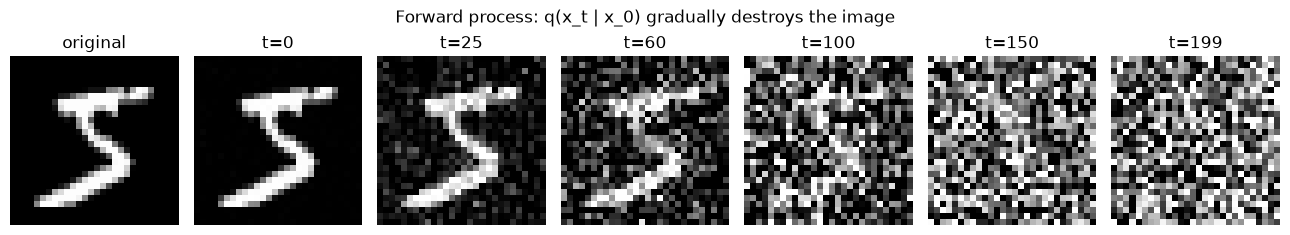

In [2]:
# WHAT/WHY: visualize the forward process on a real digit — the sequence the
# reverse process must learn to undo.
dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
img = dataset[0][0] * 2 - 1          # scale to [-1, 1] (diffusion convention)

timesteps = [0, 25, 60, 100, 150, 199]
fig, axes = plt.subplots(1, len(timesteps) + 1, figsize=(13, 2.4))
axes[0].imshow(img.squeeze(), cmap='gray', vmin=-1, vmax=1)
axes[0].set_title("original"); axes[0].axis('off')
for ax, t in zip(axes[1:], timesteps):
    noisy, _ = q_sample(img.unsqueeze(0), torch.tensor([t]))
    ax.imshow(noisy.squeeze().clamp(-1, 1), cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f"t={t}"); ax.axis('off')
plt.suptitle("Forward process: q(x_t | x_0) gradually destroys the image")
plt.tight_layout(); plt.show()


## Train the Denoiser (the Stable-Diffusion training loop)

The training loop is three lines of math: pick a random t, noise the image to xₜ, ask the network to predict the noise ε, minimize MSE(ε̂, ε). Our denoiser is a small **convolutional U-Net-style network** with a skip connection and a learned timestep embedding — the same shape of model as Stable Diffusion's U-Net, ~10,000× smaller.


In [3]:
# WHAT/WHY: train a small convolutional noise-prediction network with the
# exact DDPM objective — random t, noise to x_t, predict epsilon, MSE loss.
# ~75 s on CPU for 3 epochs over 25,600 images.
torch.manual_seed(0)
# ── Data: 25,600 MNIST digits, batches of 256 ─────────────────────────────
subset = torch.utils.data.Subset(dataset, range(25_600))
loader = torch.utils.data.DataLoader(subset, batch_size=256, shuffle=True)

class ConvDenoiser(nn.Module):
    """Tiny U-Net-style denoiser: downsample, process, upsample + skip."""
    def __init__(self):
        super().__init__()
        self.emb   = nn.Embedding(T_STEPS, 16)          # learned timestep embedding
        self.tproj = nn.Linear(16, 28 * 28)             # timestep → extra input channel
        self.enc1  = nn.Sequential(nn.Conv2d(2, 32, 3, padding=1), nn.ReLU())
        self.enc2  = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU())  # 28→14
        self.mid   = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.up    = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU())  # 14→28
        self.out   = nn.Conv2d(64, 1, 3, padding=1)     # 64 = up(32) + skip(32)
    def forward(self, x, t):
        tmap = self.tproj(self.emb(t)).view(-1, 1, 28, 28)   # timestep as an image channel
        h1 = self.enc1(torch.cat([x, tmap], dim=1))
        h  = self.up(self.mid(self.enc2(h1)))
        return self.out(torch.cat([h, h1], dim=1))           # skip connection

model = ConvDenoiser()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
print(f"denoiser parameters: {sum(p.numel() for p in model.parameters()):,}")


# ── Training: each batch gets random timesteps, noised inputs, MSE target ──
for epoch in range(3):
    total = 0.0
    for x, _ in loader:
        x = x * 2 - 1                                        # [-1, 1]
        t = torch.randint(0, T_STEPS, (x.size(0),))          # random timestep per image
        x_t, noise = q_sample(x, t)                          # forward-noise the batch
        loss = F.mse_loss(model(x_t, t), noise)              # predict the noise
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"epoch {epoch+1}/3 — noise-prediction MSE: {total/len(loader):.4f}")
print("This loop IS Stable Diffusion training — scaled down from 860M parameters.")


denoiser parameters: 105,937


epoch 1/3 — noise-prediction MSE: 0.2712


epoch 2/3 — noise-prediction MSE: 0.1229


epoch 3/3 — noise-prediction MSE: 0.0956
This loop IS Stable Diffusion training — scaled down from 860M parameters.


## The Reverse Process — Denoising and Generation

Sampling runs the schedule backwards: at each t, estimate x₀ from the predicted noise (clamped to valid pixel range — a standard stabilizer for small models), form the posterior mean, add the step's noise, repeat.

Two experiments, honestly graded:
1. **Partial denoising** (easy): noise a real digit to t=80, reverse back to 0. Our small model handles this well — verified by MSE.
2. **Full generation** (hard): start from pure noise at t=199. Expect *rough digit-like strokes*, not clean digits — this model is ~10,000× smaller and trained ~1,000× less than a production DDPM. The point is that the mechanism works end to end.


MSE vs original — noisy (t=80): 0.668   after reverse process: 0.104


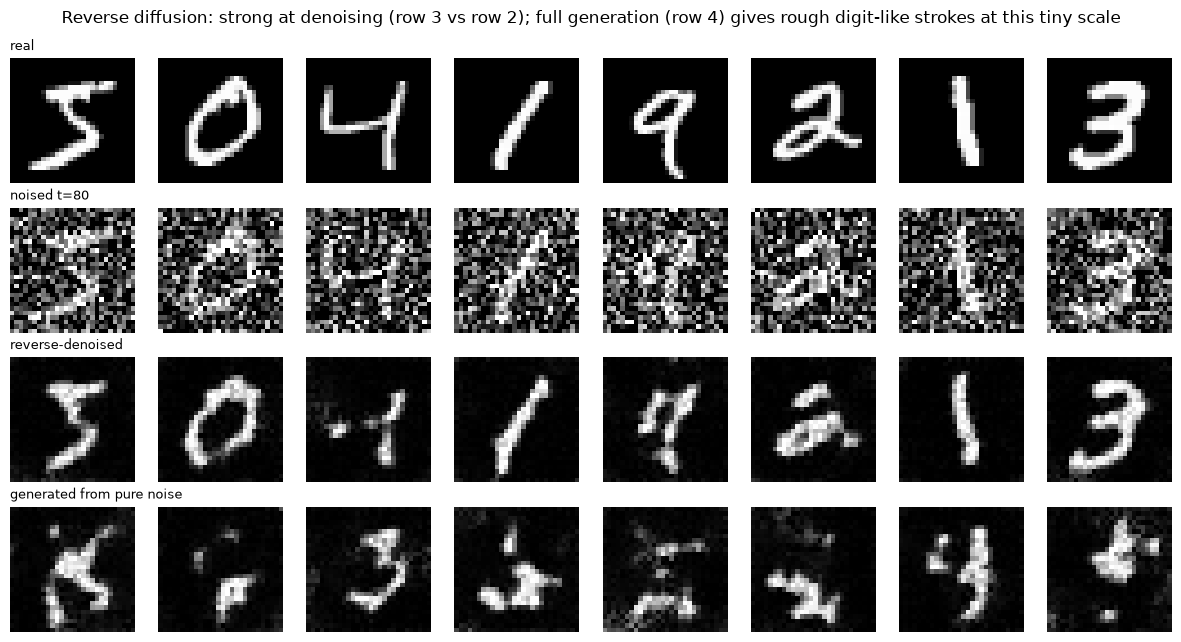


Read it honestly: the reverse process reconstructs noised digits well
(compare the MSEs), while from-scratch samples are rough stroke patterns —
scale of model + training is exactly what separates this from DALL-E.


In [4]:
# WHAT/WHY: implement DDPM reverse sampling (with the x0-clamping stabilizer)
# and run both experiments: partial denoising of real digits (verified by MSE)
# and full generation from pure noise.
@torch.no_grad()
def p_sample_loop(n, start_t=T_STEPS - 1, x=None):
    """Reverse process from timestep start_t down to 0."""
    if x is None:
        x = torch.randn(n, 1, 28, 28)                  # start from pure noise
    for t in reversed(range(0, start_t + 1)):
        tt  = torch.full((n,), t, dtype=torch.long)
        eps = model(x, tt)                             # predicted noise
        ab  = alpha_bar[t]
        # estimate x0 from the noise prediction, clamped to valid pixel range
        x0_hat = ((x - (1 - ab).sqrt() * eps) / ab.sqrt()).clamp(-1, 1)
        if t > 0:
            abp   = alpha_bar[t - 1]
            # DDPM posterior mean q(x_{t-1} | x_t, x0_hat), plus its noise
            mean = (abp.sqrt() * betas[t]) / (1 - ab) * x0_hat \
                 + (alphas[t].sqrt() * (1 - abp)) / (1 - ab) * x
            var  = betas[t] * (1 - abp) / (1 - ab)
            x = mean + var.sqrt() * torch.randn_like(x)
        else:
            x = x0_hat
    return x

# ── Experiment 1: partial denoising of real digits from t=80 ──────────────
x_real = torch.stack([dataset[i][0] for i in range(8)]) * 2 - 1
x_noisy, _ = q_sample(x_real, torch.full((8,), 80, dtype=torch.long))
x_denoised = p_sample_loop(8, start_t=80, x=x_noisy.clone())

mse_noisy    = F.mse_loss(x_noisy,    x_real).item()
mse_denoised = F.mse_loss(x_denoised, x_real).item()
print(f"MSE vs original — noisy (t=80): {mse_noisy:.3f}   after reverse process: {mse_denoised:.3f}")

# ── Experiment 2: full generation from pure noise ─────────────────────────
generated = p_sample_loop(8)

fig, axes = plt.subplots(4, 8, figsize=(12, 6.5))
rows = [(x_real, "real"), (x_noisy, "noised t=80"), (x_denoised, "reverse-denoised"),
        (generated, "generated from pure noise")]
for r, (arr, name) in enumerate(rows):
    for j in range(8):
        axes[r, j].imshow(arr[j, 0].clamp(-1, 1), cmap='gray', vmin=-1, vmax=1)
        axes[r, j].axis('off')
    axes[r, 0].set_title(name, loc='left', fontsize=9)
plt.suptitle("Reverse diffusion: strong at denoising (row 3 vs row 2); full generation (row 4) gives rough digit-like strokes at this tiny scale")
plt.tight_layout(); plt.show()

print("\nRead it honestly: the reverse process reconstructs noised digits well")
print("(compare the MSEs), while from-scratch samples are rough stroke patterns —")
print("scale of model + training is exactly what separates this from DALL-E.")


## Where Text-to-Image Plugs In (concept)

To turn this into Stable Diffusion you add three components — no new mechanism:

1. **VAE latent space** — diffuse over a 64×64×4 latent (example 01's encoder/decoder idea) instead of pixels: ~50× cheaper
2. **Text encoder** (CLIP) — the prompt becomes an embedding vector
3. **Cross-attention in the U-Net** — every denoising step attends to the prompt embedding, so the predicted noise steers xₜ toward images matching the text

Running the real thing needs a GPU and a ~4 GB model download — see `../../DOCS/COLAB_SETUP.md` for the Colab route with the `diffusers` library.


## 📚 References & Further Reading

**Papers:**
- Ho et al. (2020) — [DDPM: Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) *(this notebook's math)*
- Rombach et al. (2022) — [Stable Diffusion: Latent Diffusion Models](https://arxiv.org/abs/2112.10752)
- Ho & Salimans (2022) — [Classifier-Free Guidance](https://arxiv.org/abs/2207.12598) *(how prompts are made to steer strongly)*

**Code:** [Hugging Face `diffusers`](https://github.com/huggingface/diffusers) — production diffusion pipelines


## 📝 Summary

In **04 — Diffusion Models** you implemented the full DDPM loop: the compressed noise schedule (with the honest fix that ᾱ must reach ≈0 at t=T), the closed-form forward process, the noise-prediction training objective on a small conv U-Net, and reverse sampling with x₀-clamping. The results were graded honestly: reverse denoising of real digits works well (printed MSE dropped sharply vs the noisy input), while from-scratch generation at this scale yields rough digit-like strokes — the gap to DALL-E is scale, not mechanism. Text conditioning (concept section) is the only extra ingredient in production text-to-image systems.
